In [1]:
# ============================================================
# JUPYTER
# ============================================================

# USE:
# %matplotlib widget

In [2]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path

import sys
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# PROJECT ROOT
# ============================================================

PROJECT_ROOT = Path().resolve().parent.parent

sys.path.append(
    str(PROJECT_ROOT)
)

# ============================================================
# DATA
# ============================================================

from src.data.wwii_predictive_analysis_scalability_of_conflict import (
    load_data
)

# ============================================================
# FEATURES
# ============================================================

from src.features.build_temporal_generation_wars_deaths import (
    expand_conflicts_monthly
)

from src.features.build_features_wars_deaths import (
    build_features
)

# ============================================================
# MODELS
# ============================================================

from src.models.train_model_wars_deaths import (
    temporal_split,
    train_model,
    evaluate_model,
    feature_importance,
    save_model
)


Loading WWII Dataset...

Dataset Shape:
(10000, 12)

Columns:
['event_id', 'start_year', 'end_year', 'country', 'alliance', 'casualties_mil_k', 'casualties_civ_k', 'military_personnel_k', 'front', 'total_casualties_k', 'casualty_ratio', 'war_name']

Generating Monthly Timeline...
Processing 0/10,000
Processing 1,000/10,000
Processing 2,000/10,000
Processing 3,000/10,000
Processing 4,000/10,000
Processing 5,000/10,000
Processing 6,000/10,000
Processing 7,000/10,000
Processing 8,000/10,000
Processing 9,000/10,000

Expanded Shape:
(719160, 13)

Building Features...

Feature Engineering Completed.

Target Distribution:
next_month_escalation
0    0.619171
1    0.380829
Name: proportion, dtype: float64

Temporal Dataset Saved.
C:\Users\Ersbr\Pictures\Que_Saco\international-conflict-risk-ml\data\generated\advanced_temporal_conflict_dataset_wwii.parquet

Applying Temporal Split...

Training LightGBM...
[LightGBM] [Info] Number of positive: 229923, number of negative: 373261
[LightGBM] [Info] 

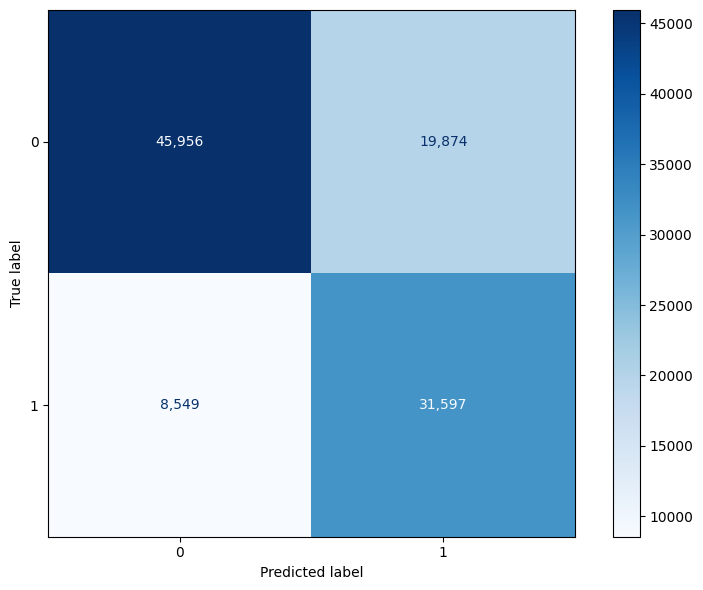


Feature Importance:

                 feature  importance
0         current_deaths        2236
10                ewma_6        1966
7         rolling_mean_3        1598
14      casualties_mil_k        1287
15      casualties_civ_k        1044
3                  lag_3        1002
8         rolling_mean_6         973
11              momentum         737
12            volatility         729
1                  lag_1         594
6            growth_rate         542
9          rolling_std_6         498
2                  lag_2         444
16  military_personnel_k         381
5                delta_2         380
4                delta_1         337
17        casualty_ratio         309
13          acceleration         240
18       country_encoded         106
20         front_encoded          75
19      alliance_encoded          10
21      war_name_encoded           0

Model Saved:
C:\Users\Ersbr\Pictures\Que_Saco\international-conflict-risk-ml\models\advanced_temporal_conflict_model_wars_deat

In [3]:
# ============================================================
# LOAD DATA
# ============================================================

raw_df = load_data()

# ============================================================
# TEMPORAL GENERATION
# ============================================================

temporal_df = expand_conflicts_monthly(
    raw_df
)

# ============================================================
# FEATURE ENGINEERING
# ============================================================

feature_df, features = build_features(
    temporal_df
)

# ============================================================
# GENERATED DIRECTORY
# ============================================================

GENERATED_DIR = (
    PROJECT_ROOT /
    "data" /
    "generated"
)

GENERATED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ============================================================
# TEMPORAL DATASET
# ============================================================

TEMPORAL_DATASET = (
    GENERATED_DIR /
    "advanced_temporal_conflict_dataset_wwii.parquet"
)

feature_df.to_parquet(
    TEMPORAL_DATASET,
    index=False
)

print("\nTemporal Dataset Saved.")

print(TEMPORAL_DATASET)

# ============================================================
# TEMPORAL SPLIT
# ============================================================

(
    X_train,
    X_test,
    y_train,
    y_test

) = temporal_split(
    feature_df,
    features
)

# ============================================================
# TRAIN MODEL
# ============================================================

model = train_model(
    X_train,
    y_train
)

# ============================================================
# EVALUATE MODEL
# ============================================================

evaluate_model(
    model,
    X_test,
    y_test
)

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance(
    model,
    features
)

# ============================================================
# SAVE MODEL
# ============================================================

save_model(model)

# ============================================================
# FINISHED 
# ============================================================

print("\nPipeline Completed Successfully.")